# Code for analysing party program data

#### source
https://dnpprepo.ub.rug.nl/view/verkiezingsprogramma/tweede=5Fkamerverkiezingen.date.html#group_2023

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import matplotx

In [9]:
df = pd.read_csv('elections_data_with_relevant_sections.csv')
df.head()

,relation,title,date,type,format,language,identifier_urls,identifier_citation,extracted_text,party,cleaned_text,ai_related,matched_keywords_all,relevant_section
0,https://dnpprepo.ub.rug.nl/88759/,Aanpassen aan de draagkracht van de aarde,2025,"[""Verkiezingsprogramma's"", 'NonPeerReviewed']",text,nl,https://dnpprepo.ub.rug.nl/88759/1/DeGroenen%2...,De Groenen (2025) Aanpassen aan de draagkrach...,Aanpassen aan \nde draagkracht \nvan de aarde\...,De Groenen,Aanpassen aan de draagkracht van de aarde DE G...,no,['drones'],...rights in the occupied Palestinian territor...
1,https://dnpprepo.ub.rug.nl/88739/,BBB levert,2025,"[""Verkiezingsprogramma's"", 'NonPeerReviewed']","['text', 'text']","['nl', 'nl']",https://dnpprepo.ub.rug.nl/88739/7/BBB%20Verki...,BoerBurgerBeweging (2025) BBB levert. [Verki...,Verkiezingsprogramma\n2025 - 2029\n\n Dankwoor...,BoerBurgerBeweging,Verkiezingsprogramma 2025 - 2029 Dankwoord Lie...,yes,"['ai', 'drone', 'drones']",...ruimte laat voor urgentie of realiteitszin....
2,https://dnpprepo.ub.rug.nl/88765/,Bouwen op vertrouwen,2025,"[""Verkiezingsprogramma's"", 'NonPeerReviewed']","['text', 'text']","['nl', 'nl']",https://dnpprepo.ub.rug.nl/88765/7/CDA%20Verki...,CDA (2025) Bouwen op vertrouwen. [Verkiezing...,Bouwen op\nvertrouwen.\n\nOnze keuzes voor\nee...,CDA,Bouwen op vertrouwen. Onze keuzes voor een fat...,yes,"['ai', 'algoritmes', 'gpt', 'kunstmatige intel...",...Als mantelzorger of reservist. Waar mensen ...
3,https://dnpprepo.ub.rug.nl/88762/,De juiste aanpak voor Nederland,2025,"[""Verkiezingsprogramma's"", 'NonPeerReviewed']","['text', 'text']","['nl', 'nl']",https://dnpprepo.ub.rug.nl/88762/7/JA21%20Verk...,JA21 (2025) De juiste aanpak voor Nederland. ...,eiligheid\n\n V\ne\nz\nn\nO\n\nOnze Gr\n\ne\nn...,JA21,eiligheid V e z n O Onze Gr e n z e n Onze Wel...,yes,"['ai', 'drones', 'kunstmatige intelligentie']",...gemiddelden waarmee men uitsluitend op papi...
4,https://dnpprepo.ub.rug.nl/88774/,"De mens centraal, niet het systeem",2025,"[""Verkiezingsprogramma's"", 'NonPeerReviewed']",text,nl,https://dnpprepo.ub.rug.nl/88774/1/Piratenpart...,"Piratenpartij (2025) De mens centraal, niet h...",Verkiezingsprogramma Piratenpartij \nNederland...,Piratenpartij,Verkiezingsprogramma Piratenpartij Nederland 2...,yes,"['facebook', 'google', 'ai', 'algoritme', 'alg...",...betaalbare woningen goede zorg en onderwijs...


In [27]:
# keep ai related programs only
df_ai_only = df[df['ai_related'] == 'yes']
df_ai_only.info()

<class 'pandas.DataFrame'>
Index: 91 entries, 1 to 331
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   relation              91 non-null     str  
 1   title                 91 non-null     str  
 2   date                  91 non-null     int64
 3   type                  91 non-null     str  
 4   format                91 non-null     str  
 5   language              91 non-null     str  
 6   identifier_urls       91 non-null     str  
 7   identifier_citation   91 non-null     str  
 8   extracted_text        91 non-null     str  
 9   party                 91 non-null     str  
 10  cleaned_text          91 non-null     str  
 11  ai_related            91 non-null     str  
 12  matched_keywords_all  91 non-null     str  
 13  relevant_section      91 non-null     str  
dtypes: int64(1), str(13)
memory usage: 10.7 KB


In [28]:
# how many ai related programs?
df['ai_related'].value_counts()

ai_related
no     242
yes     91
Name: count, dtype: int64

In [23]:
# How many programs
len(df)

333

In [11]:
df['date'].value_counts()

date
2018    110
2017     80
2021     44
2025     29
2023     29
2019     21
2024     19
2020      1
Name: count, dtype: int64

## combined plots

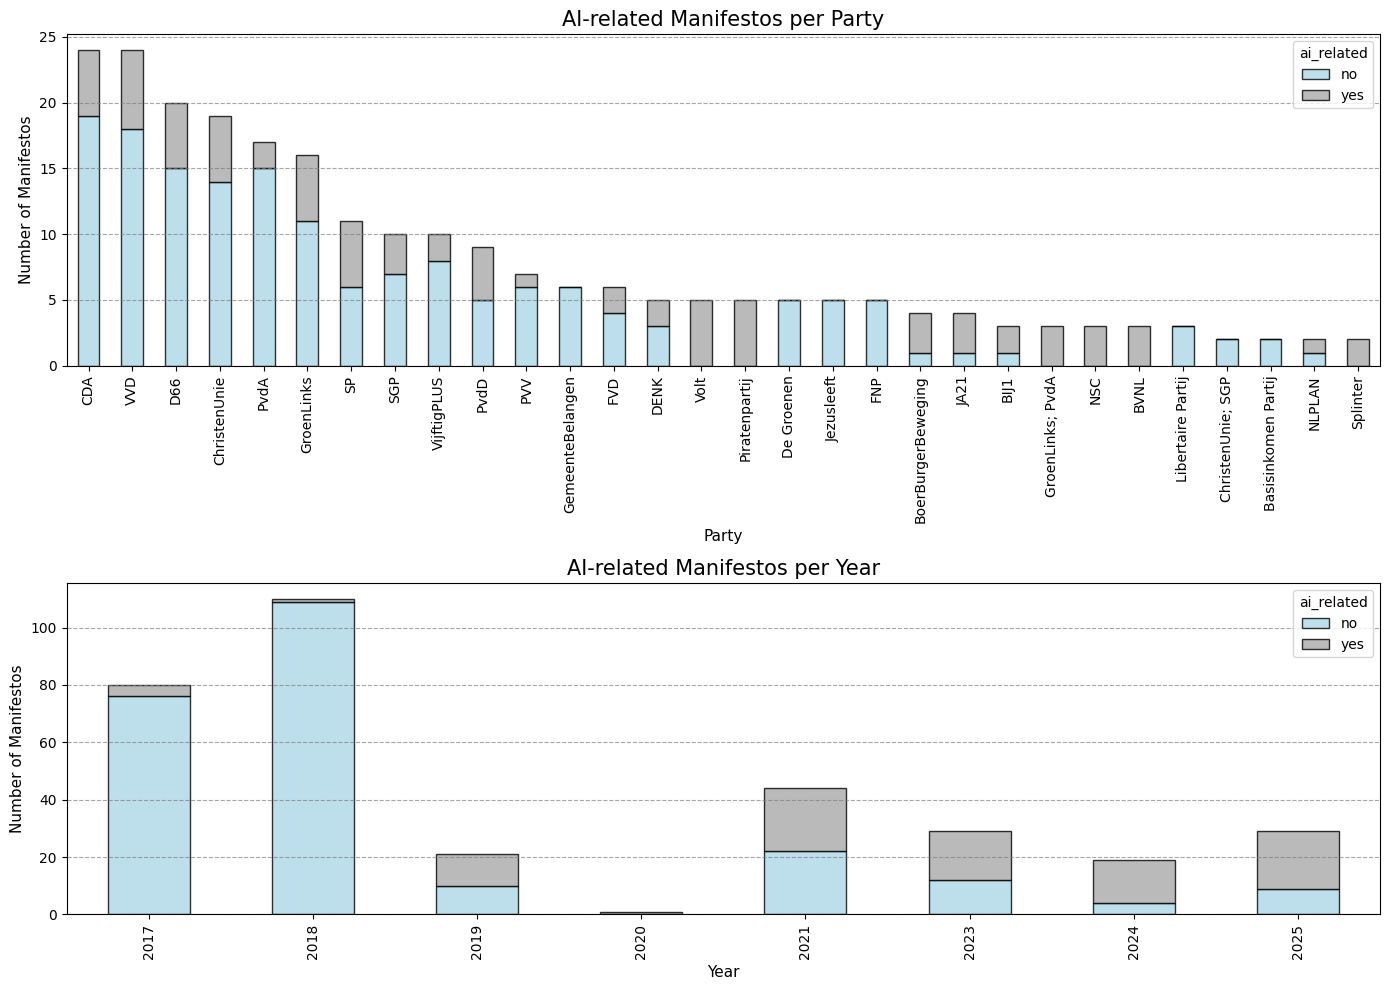

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# -------------------------
# 3. AI-related programs per party
# -------------------------

# bepaal top 10 partijen op basis van aantal rijen
top10 = df['party'].value_counts().nlargest(30).index

table = (
    df[df['party'].isin(top10)]
      .groupby(['party', 'ai_related'])
      .size()
      .unstack(fill_value=0)
)

# sorteer op totaal aantal programma's (som over de kolommen)
table = table.reindex(
    table.sum(axis=1).sort_values(ascending=False).index
)

table.plot(
    kind='bar',
    stacked=True,
    color=["lightblue", "darkgrey"],
    edgecolor="black",
    alpha=0.8,
    ax=axes[0]
)

axes[0].set_xlabel('Party', fontsize=11, fontfamily='DejaVu Sans')
axes[0].set_ylabel('Number of Manifestos', fontsize=11, fontfamily='DejaVu Sans')
axes[0].set_title('AI-related Manifestos per Party', fontsize=15, fontfamily='DejaVu Sans')
axes[0].grid(axis='y', linestyle='--', alpha=0.7, color='gray')



# -------------------------
# 4. AI-related programs per year
# -------------------------
df['ai_related'] \
    .groupby(df['date']) \
    .value_counts() \
    .unstack() \
    .fillna(0) \
    .plot(
        kind='bar',
        stacked=True,
        color=["lightblue", "darkgrey"],
        edgecolor="black",
        alpha=0.8,
        ax=axes[1]
    )

axes[1].set_xlabel('Year', fontsize=11, fontfamily='DejaVu Sans')
axes[1].set_ylabel('Number of Manifestos', fontsize=11, fontfamily='DejaVu Sans')
axes[1].set_title('AI-related Manifestos per Year', fontsize=15, fontfamily='DejaVu Sans')
axes[1].grid(axis='y', linestyle='--', alpha=0.7, color='gray')

plt.tight_layout()
plt.show()

### Analysis

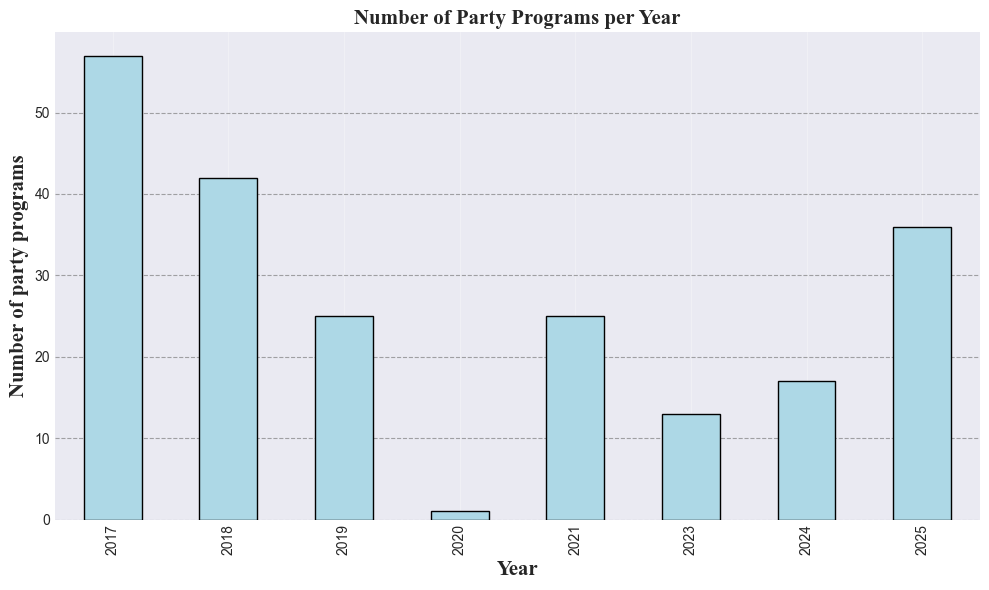

In [65]:

# plot number of programs per year

df['year'].value_counts().sort_index().plot(kind='bar', color="lightblue", edgecolor="black")
plt.xlabel('Year', fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.ylabel('Number of party programs', fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.title('Number of Party Programs per Year', fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
# change fontstyle


# show grid
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
plt.tight_layout()
plt.show()

In [9]:
# how many rows are ai_related == True
df['ai_related'].value_counts()


ai_related
no     153
yes     63
Name: count, dtype: int64

In [29]:



plt.bar(sorted_keyword_counts.keys(),
        sorted_keyword_counts.values(),
        color="lightblue", edgecolor="black", alpha=0.8)

plt.grid(True, linestyle="--", alpha=0.3)
plt.xticks(rotation=90)
plt.xlabel("Keywords", fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.ylabel("Counts", fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.title("Keyword Counts", fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
#show grid
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray')

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

NameError: name 'sorted_keyword_counts' is not defined

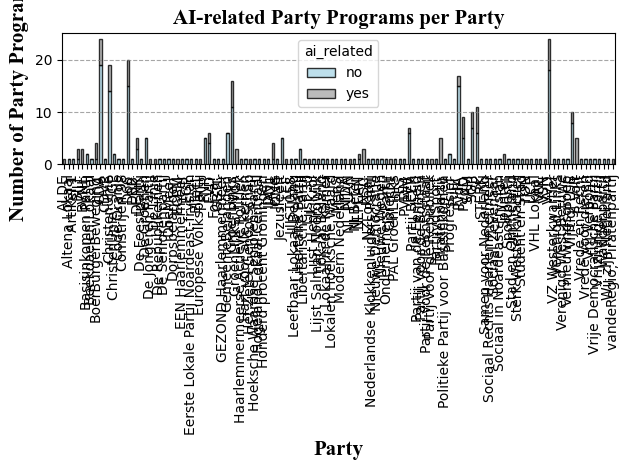

In [30]:

df['ai_related'] \
    .groupby(df['party']) \
    .value_counts() \
    .unstack() \
    .fillna(0) \
    .plot(kind='bar', stacked=True, color=["lightblue", "darkgrey"], edgecolor="black", alpha=0.8)

plt.xlabel('Party', fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.ylabel('Number of Party Programs', fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.title('AI-related Party Programs per Party', fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.tight_layout()
# show grid
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
plt.show()

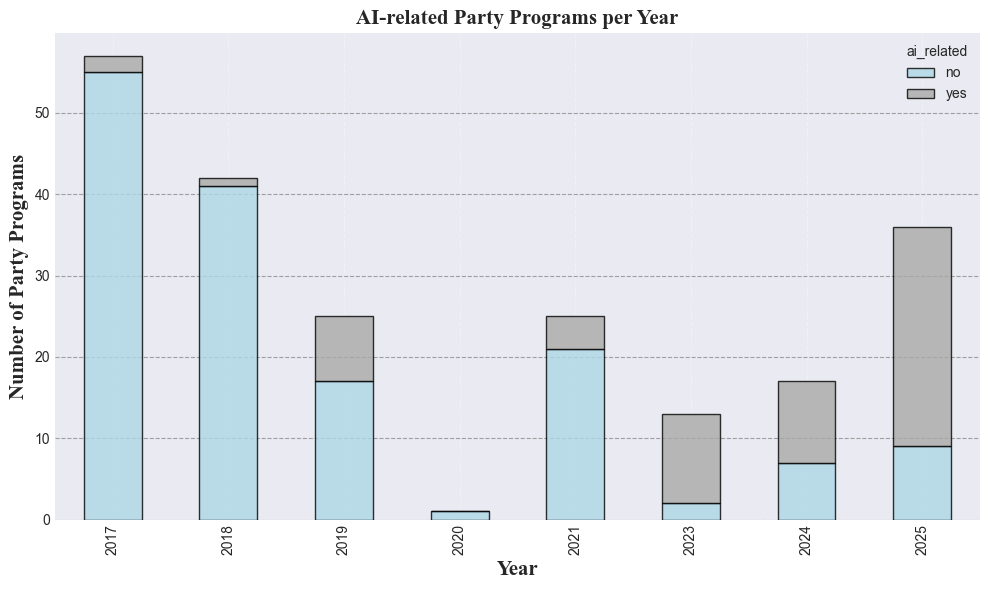

In [75]:


df['ai_related'] \
    .groupby(df['year']) \
    .value_counts() \
    .unstack() \
    .fillna(0) \
    .plot(kind='bar', stacked=True, color=["lightblue", "darkgrey"], edgecolor="black", alpha=0.8)

plt.xlabel('Year', fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.ylabel('Number of Party Programs', fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.title('AI-related Party Programs per Year', fontsize=15, fontweight='bold', fontfamily='serif', fontname='Times New Roman')
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
plt.tight_layout()
plt.show()

In [93]:
import re
import ast
import pandas as pd

def _norm_matched_keywords(val):
    """
    Normalize matched_keywords_all into a list[str].
    Accepts: list/set/tuple, stringified list (e.g. "['ai','ml']"),
             or comma-separated string ("ai, machine learning").
    """
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return []
    if isinstance(val, (list, set, tuple)):
        kws = list(val)
    elif isinstance(val, str):
        s = val.strip()
        if not s:
            return []
        # Try to parse stringified list
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, set, tuple)):
                kws = list(parsed)
            else:
                # fallback: treat as comma-separated
                kws = [x.strip() for x in s.split(",") if x.strip()]
        except Exception:
            kws = [x.strip() for x in s.split(",") if x.strip()]
    else:
        return []

    # clean, dedupe, keep phrases
    out = []
    seen = set()
    for k in kws:
        if not isinstance(k, str):
            continue
        k2 = k.strip()
        if not k2:
            continue
        kl = k2.lower()
        if kl not in seen:
            seen.add(kl)
            out.append(k2)
    return out

def _extract_windows(text, keywords, window=5, max_snippets=5):
    """
    Build a plain-text section composed of ±window words around each keyword hit.
    Returns: (section_text, spans, n_matches)
    """
    if not isinstance(text, str) or not text.strip():
        return "", [], 0
    keywords = _norm_matched_keywords(keywords)
    if not keywords:
        return "", [], 0

    # Safer "word boundary" for phrases: (?<!\w) ... (?!\w)
    # (handles multi-word phrases and punctuation better than \b ... \b)
    alts = [re.escape(k) for k in keywords]
    pattern = r'(?<!\w)(?:' + '|'.join(alts) + r')(?!\w)'
    flags = re.IGNORECASE

    matches = list(re.finditer(pattern, text, flags))
    if not matches:
        return "", [], 0

    # Word spans to take ±window words
    word_spans = [(m.start(), m.end()) for m in re.finditer(r'\S+', text)]

    def word_index_for_pos(pos):
        # small linear scan is fine for typical lengths
        for i, (s, e) in enumerate(word_spans):
            if s <= pos < e:
                return i
        # if match starts on whitespace, snap to next word
        for i, (s, e) in enumerate(word_spans):
            if pos < e:
                return i
        return len(word_spans) - 1 if word_spans else 0

    spans = []
    for m in matches:
        wi = word_index_for_pos(m.start())
        start_w = max(0, wi - window)
        end_w   = min(len(word_spans), wi + window + 1)
        start_c = word_spans[start_w][0]
        end_c   = word_spans[end_w - 1][1]

        if spans and start_c <= spans[-1][1]:
            spans[-1] = (spans[-1][0], max(spans[-1][1], end_c))
        else:
            spans.append((start_c, end_c))

    spans = spans[:max_snippets]

    parts = []
    for i, (s, e) in enumerate(spans):
        prefix = '...' if (i == 0 and s > 0) else ''
        suffix = '...' if (i == len(spans)-1 and e < len(text)) else ''
        parts.append(prefix + text[s:e].strip() + suffix)

    section_text = ' '.join(parts)
    return section_text, spans, len(matches)

def add_relevant_section(df, body_col='body', matched_col='matched_keywords_all',
                         window=5, max_snippets=5):
    """
    Adds:
      - relevant_section (plain text)
      - relevant_section_spans (char spans)
      - n_keyword_matches
      - relevant_len_chars
      - relevant_len_words
    """
    results = df.apply(
        lambda r: _extract_windows(
            str(r[body_col]) if pd.notna(r.get(body_col)) else "",
            r.get(matched_col),
            window,
            max_snippets
        ),
        axis=1
    )
    df['relevant_section']       = results.map(lambda t: t[0])
    df['relevant_section_spans'] = results.map(lambda t: t[1])
    df['n_keyword_matches']      = results.map(lambda t: t[2])
    df['relevant_len_chars']     = df['relevant_section'].str.len()
    df['relevant_len_words']     = df['relevant_section'].str.count(r'\b\w+\b')
    return df


In [94]:
df_relevant = add_relevant_section(df, body_col='body', matched_col='matched_keywords_all', window=20)
df_relevant

,party,year,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,relevant_section,relevant_section_spans,n_keyword_matches,relevant_len_chars,relevant_len_words
0,BIJ1,2025,Doe eerlijk. Doe eerlijk. STEM Tweede Kamer ve...,no,[],['ai'],['ai'],0,1,...kennis in de wapenindustrie voor de civiele...,"[(80246, 80522)]",1,282,41
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","['ai', 'artificiële intelligentie', 'kunstmati...",0,4,...met specifieke aandacht voor internetgebrui...,"[(15118, 15544), (22237, 22511)]",5,707,96
2,50PLUS,2019,1 Onze toekomst in Europa. Solidair met jong e...,no,[],[],[],0,0,,[],0,0,0
3,GroenLinks,2019,Resolution: Freedom opportunity prosperity: th...,yes,[],['artificial intelligence'],['artificial intelligence'],0,2,...judicial independence and freedom of the pr...,"[(5703, 6007), (22976, 23224)]",2,559,82
4,DENK,2018,LIJST 1 SAMEN MAKEN WIJ ER WERK VAN Vooraf Eco...,no,[],[],[],0,0,,[],0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,DENK,2025,1 VRIJ VERBOND VERKIEZINGS- PROGRAMMA 2025 – 2...,no,[],[],[],0,0,,[],0,0,0
212,VVD,2019,PROGRAMMACOMMISSIE Ruben Brekelmans Debbie van...,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,6,...Ambitieus doel voor CO2- reductie op Europe...,"[(1703, 2022), (8303, 8604), (23626, 23925), (...",6,1532,208
213,DENK,2017,Concept verkiezingsprogramma 2017-2021 ZEKER N...,no,[],[],[],0,0,,[],0,0,0
214,DENK,2017,VVD verkiezingsprogramma 2017-2021 ZEKER NEDER...,no,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,1,...vrijheden. En dat die waarden niet onderhan...,"[(20796, 21095)]",1,305,41


In [95]:
# add total word count of body column
df_relevant['total_len_words'] = df_relevant['body'].str.count(r'\b\w+\b')

In [96]:
#only keep relevant rows
df_relevant_only = df_relevant[df_relevant['ai_related'] == 'yes']
df_relevant_only

,party,year,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,relevant_section,relevant_section_spans,n_keyword_matches,relevant_len_chars,relevant_len_words,total_len_words
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","['ai', 'artificiële intelligentie', 'kunstmati...",0,4,...met specifieke aandacht voor internetgebrui...,"[(15118, 15544), (22237, 22511)]",5,707,96,4169
3,GroenLinks,2019,Resolution: Freedom opportunity prosperity: th...,yes,[],['artificial intelligence'],['artificial intelligence'],0,2,...judicial independence and freedom of the pr...,"[(5703, 6007), (22976, 23224)]",2,559,82,5773
7,BBB,2023,Visie en Verkiezingsprogramma 2023-2027 Van Ve...,yes,[],"['ai', 'artificial intelligence', 'kunstmatige...","['ai', 'artificial intelligence', 'kunstmatige...",0,8,...zowel aan docenten als aan leerlingen gegev...,"[(337909, 338171), (357517, 357828), (358520, ...",8,1426,207,91202
8,BBB,2024,SAMENVATTING BBB VERKIEZINGSPROGRAMMA EUROPEES...,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,2,...voor onderzoek breder inzetten en het MKB e...,"[(10854, 11200)]",2,352,49,3798
9,BBB,2024,BBB VERKIEZINGSPROGRAMMA EUROPEES PARLEMENT 20...,yes,[],"['ai', 'artificial intelligence', 'kunstmatige...","['ai', 'artificial intelligence', 'kunstmatige...",0,12,...noodzakelijke investeringen kunnen doen maa...,"[(68064, 69007), (69027, 69406), (91475, 91731...",13,1890,280,23619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,Volt,2018,Volt’s programme for the European Parliament 2...,yes,[],"['ai', 'artificial intelligence']","['ai', 'artificial intelligence']",0,22,...and ESF+. Boost entrepreneurship and the cr...,"[(75235, 75513), (80945, 81210), (84265, 85353...",22,2657,434,23250
204,Volt,2019,Volt’s programme for the European Parliament 2...,yes,[],"['ai', 'artificial intelligence']","['ai', 'artificial intelligence']",0,9,...> Boost entrepreneurship and the creation o...,"[(11711, 11985), (12275, 12533), (12647, 13394)]",9,1287,202,3582
205,Volt,2024,Het programma van Volt voor het Europees Parle...,yes,[],['kunstmatige intelligentie'],['kunstmatige intelligentie'],0,4,...EU worden vereenvoudigd. > Stimuleer ondern...,"[(12829, 13142), (13443, 13729), (13951, 14451)]",4,1107,154,3718
206,Volt,2025,VERKIEZINGSPROGRAMMA Volt Nederland 1 Verkiezi...,yes,[],"['ai', 'chatgpt', 'generatieve ai', 'gpt', 'ku...","['ai', 'chatgpt', 'generatieve ai', 'gpt', 'ku...",0,71,...elkaar laat spelen verstopt Nederland zich ...,"[(975, 1225), (2936, 3216), (9695, 9935), (100...",77,1392,212,57568


In [97]:
# make sure matched_keywords_all is list
for idx, row in df_relevant_only.iterrows():
    if isinstance(row['matched_keywords_all'], str):
        try:
            df_relevant_only.at[idx, 'matched_keywords_all'] = ast.literal_eval(row['matched_keywords_all'])
        except (ValueError, SyntaxError):
            df_relevant_only.at[idx, 'matched_keywords_all'] = []
df_relevant_only['matched_keywords_all'].iloc[1]

ValueError: Must have equal len keys and value when setting with an iterable

### Inspect examples

In [18]:
import re
import pandas as pd
from html import escape
from IPython.display import display, HTML

def inspect_ai_related(df, num_samples=30, random_state=42):
    """
    Displays random samples with highlighted *matched* keywords.
    Uses df['matched_keywords_all'] per row instead of a global keyword list.
    Works even if 'title' column is missing.
    """

    # --- sanity checks ---
    if 'ai_related' not in df.columns:
        raise KeyError("DataFrame must contain an 'ai_related' column.")
    if 'body' not in df.columns:
        raise KeyError("DataFrame must contain a 'body' column.")
    if 'matched_keywords_all' not in df.columns:
        raise KeyError("DataFrame must contain 'matched_keywords_all'.")

    # --- sample ---
    n = min(num_samples, len(df))
    samples = df.sample(n=n, random_state=random_state)

    # --- internal highlight function ---
    def highlight_keywords(text, keywords):
        if pd.isna(text):
            return ""
        s = str(text)

        if not isinstance(keywords, (set, list)):
            raise ValueError("Keywords must be a set or list")
        kws = {str(w).strip().lower() for w in keywords if str(w).strip()}
        if not kws:
            return s

        # sort by length to avoid partial overshadowing
        ordered = sorted(kws, key=len, reverse=True)

        # custom boundary: match even inside hyphenated words
        def make_pattern(word):
            return rf'(?<![A-Za-z0-9]){re.escape(word)}(?![A-Za-z0-9])'

        combined = "|".join(make_pattern(w) for w in ordered)
        regex = re.compile(combined, flags=re.IGNORECASE)

        def repl(m):
            kw = m.group(0)
            return f'<span style="font-size:1.5em; font-weight:bold; color:green;">{escape(kw)}</span>'

        return regex.sub(repl, s)

    # --- display samples ---
    for idx, row in samples.iterrows():
        ai_val = row['ai_related']
        body   = row['relevant_section']
        title  = row.get('title', None)

        # --- use the actually matched keywords in this row ---
        matched_keywords = row.get('matched_keywords_all', [])
        if isinstance(matched_keywords, (list, set, tuple)):
            row_terms = {str(x).lower() for x in matched_keywords}
        else:
            row_terms = {str(matched_keywords).lower()} if matched_keywords else set()

        # --- highlight ---
        highlighted_body  = highlight_keywords(body, row_terms)
        highlighted_title = highlight_keywords(title, row_terms) if title is not None else None

        # --- header ---
        header_html = (
            f'<div style="margin:0.5em 0;">'
            f'<strong>Index:</strong> {idx} &nbsp; | &nbsp; '
            f'<strong>ai_related:</strong> {ai_val}'
        )
        if matched_keywords:
            header_html += f'<br><strong>matched keywords:</strong> {matched_keywords}'
        header_html += '</div>'

        # --- display ---
        display(HTML(header_html))
        if highlighted_title:
            display(HTML(f'<h3 style="margin:0.2em 0;">{highlighted_title}</h3>'))
        display(HTML(f'<div style="line-height:1.5;">{highlighted_body}</div>'))
        display(HTML('<hr>'))

    print(f"Displayed {n} random articles (with row-specific matched keywords highlighted).")
    return samples

In [19]:
inspect_ai_related(df_relevant_only, num_samples=5)

Displayed 5 random articles (with row-specific matched keywords highlighted).


,party,year,body,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,relevant_section,relevant_section_spans,n_keyword_matches,relevant_len_chars,relevant_len_words,total_len_words
206,Volt,2025,VERKIEZINGSPROGRAMMA Volt Nederland 1 Verkiezi...,yes,[],"['ai', 'chatgpt', 'generatieve ai', 'gpt', 'ku...","[ai, chatgpt, generatieve ai, gpt, kunstmatige...",0,71,...elkaar laat spelen verstopt Nederland zich ...,"[(975, 1225), (2936, 3216), (9695, 9935), (100...",77,1392,212,57568
202,VVD,2025,1 Sterker uit de storm Keuzes voor een nieuwe ...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","[ai, artificiële intelligentie, kunstmatige in...",0,24,...is gericht op start- en scale-ups zodat zij...,"[(8539, 8789), (10322, 10579), (12740, 13038),...",24,1973,300,40350
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,yes,[],"['ai', 'artificiële intelligentie', 'kunstmati...","[ai, artificiële intelligentie, kunstmatige in...",0,4,...met specifieke aandacht voor internetgebrui...,"[(15118, 15544), (22237, 22511)]",5,707,96,4169
129,D66,2017,1 D66 Verkiezingsprogramma 2017-2021 December ...,yes,[],['artificiële intelligentie'],[artificiële intelligentie],0,3,...komende jaren aangesloten op internet en ku...,"[(179720, 180030), (185161, 185470), (188953, ...",3,939,125,66102
12,BBB,2023,Visie en Verkiezingsprogramma 2023-2027 Van Ve...,yes,[],"['ai', 'artificial intelligence', 'kunstmatige...","[ai, artificial intelligence, kunstmatige inte...",0,5,...moet zowel aan docenten als aan leerlingen ...,"[(190282, 190548), (200721, 201032), (201725, ...",5,1473,206,47281


In [98]:
df_relevant_only_clean = df_relevant_only.drop(columns=['matched_keywords_title', 'matched_keywords_body', 'n_hits_title_total', 'relevant_section_spans', 'n_keyword_matches', 'relevant_len_chars'])

In [99]:
df_relevant_only_clean = df_relevant_only_clean.drop(columns=['ai_related'])

In [100]:
# rename relevant_section to ai_relevant_section
df_relevant_only_clean = df_relevant_only_clean.rename(columns={'relevant_section': 'body'})

In [119]:
df_relevant_only_clean.to_csv('party_programs_ai_relevant_sections.csv')

In [101]:
df_relevant_only_clean.head()

,party,year,body,matched_keywords_all,n_hits_body_total,body,relevant_len_words,total_len_words
1,50PLUS,2025,Verkiezingsprogramma 2025 - 2029 1 Verkiezings...,"['ai', 'artificiële intelligentie', 'kunstmati...",4,...met specifieke aandacht voor internetgebrui...,96,4169
3,GroenLinks,2019,Resolution: Freedom opportunity prosperity: th...,['artificial intelligence'],2,...judicial independence and freedom of the pr...,82,5773
7,BBB,2023,Visie en Verkiezingsprogramma 2023-2027 Van Ve...,"['ai', 'artificial intelligence', 'kunstmatige...",8,...zowel aan docenten als aan leerlingen gegev...,207,91202
8,BBB,2024,SAMENVATTING BBB VERKIEZINGSPROGRAMMA EUROPEES...,['kunstmatige intelligentie'],2,...voor onderzoek breder inzetten en het MKB e...,49,3798
9,BBB,2024,BBB VERKIEZINGSPROGRAMMA EUROPEES PARLEMENT 20...,"['ai', 'artificial intelligence', 'kunstmatige...",12,...noodzakelijke investeringen kunnen doen maa...,280,23619


In [102]:
# average words in relevant sections
df_relevant_only['relevant_len_words'].mean()

np.float64(202.68253968253967)

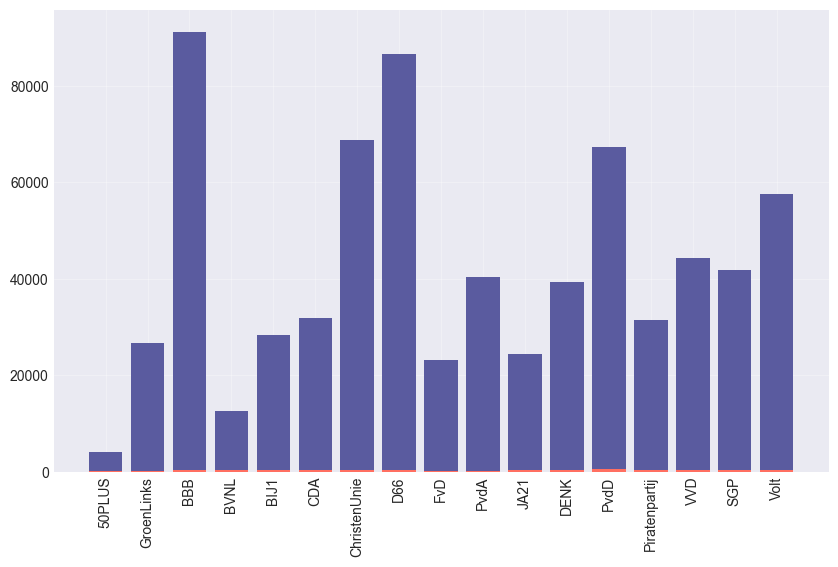

In [103]:
# show barplot relevant vs total word count
plt.style.use(matplotx.styles.pacoty)
plt.bar(df_relevant_only['party'], df_relevant_only['total_len_words'], label='Total Words')
plt.bar(df_relevant_only['party'], df_relevant_only['relevant_len_words'], label='Relevant Words')
plt.xticks(rotation=90)
plt.show()



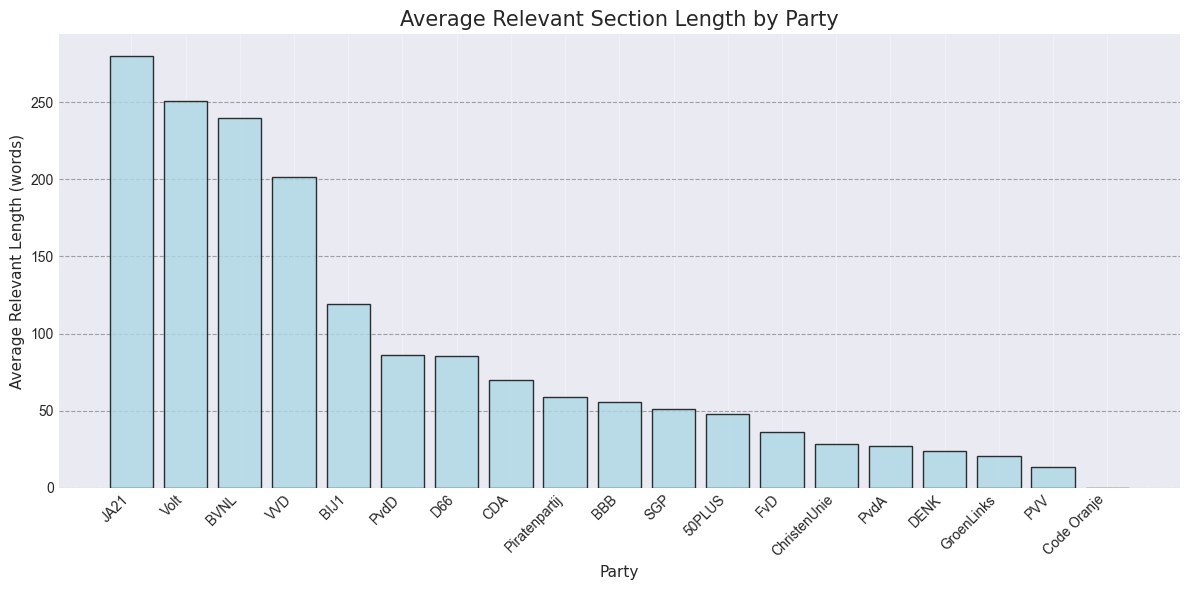

In [109]:
length_by_party = (
    df.groupby('party')['relevant_len_words']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

length_by_party


# plt.style.use(matplotx.styles.pacoty)
plt.figure(figsize=(12,6))  # make the plot wider

plt.bar(length_by_party['party'], length_by_party['relevant_len_words'], color="lightblue", edgecolor="black", alpha=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
plt.xlabel('Party', fontsize=11, fontfamily='dejaVu Sans')
plt.ylabel('Average Relevant Length (words)', fontsize=11, fontfamily='dejaVu Sans')
plt.title('Average Relevant Section Length by Party', fontsize=15, fontfamily='dejaVu Sans')

plt.xticks(rotation=45, ha='right')  # rotate labels + right-align so they don’t overlap
plt.tight_layout()                  # automatically adjust margins

plt.show()